# 05 - Modelado ML
## Credit Risk Analysis — Give Me Some Credit

**Objetivo de este notebook:**
- Separar features (X) y variable objetivo (y)
- Dividir el dataset en train y test
- Tratar el desbalanceo de clases con SMOTE
- Entrenar y comparar múltiples modelos de Machine Learning
- Evaluar los modelos con métricas apropiadas
- Seleccionar el mejor modelo

## **Nota de actualización**

El dataset original tenía 15 columnas. Tras detectar **multicolinealidad** entre`total_delays` y las columnas individuales de retrasos, se eliminaron 3 columnas en el notebook 04. El dataset actualizado tiene **12 columnas**.

Los markdowns de observaciones anteriores pueden mostrar ligeras diferencias con los resultados actuales. Los cambios más relevantes son:
- El Recall de Regresión Logística mejoró de 0.64 a 0.70
- El AUC de Regresión Logística mejoró de 0.823 a 0.835
- Esto confirma que eliminar la multicolinealidad benefició especialmente a la Regresión Logística.

In [22]:
# Importamos librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Cargamos dataset limpio
df= pd.read_csv('../data/processed/cs-training-features.csv')
df.head()

,seriousdlqin2yrs,revolvingutilizationofunsecuredlines,age,debtratio,monthlyincome,numberofopencreditlinesandloans,numberrealestateloansorlines,numberofdependents,total_delays,income_per_dependent,credit_utilization_risk,financial_margin
0,1,0.766127,45,0.802982,9120.0,13,6,2.0,2,4560.0,1,1796.802984
1,0,0.957151,40,0.121876,2600.0,4,0,1.0,0,2600.0,1,2283.121877
2,0,0.658180,38,0.085113,3042.0,2,0,0.0,2,3042.0,0,2783.085113
3,0,0.233810,30,0.036050,3300.0,5,0,0.0,0,3300.0,0,3181.036049
4,0,0.907239,49,0.024926,12627.5,7,1,0.0,1,12627.5,0,12312.750786


## Paso 1 — Separar features (X) y variable objetivo (y)

In [23]:
# Vamos a separar la variable objetivo 'SeriousDlqin2yrs' del resto de variables para facilitar el trabajo de modelado
X = df.drop('seriousdlqin2yrs', axis=1)  # Variables predictoras
y = df['seriousdlqin2yrs']  # Variable objetivo
print(X.shape)
print(y.shape)
print(y.value_counts())

(149731, 11)
(149731,)
seriousdlqin2yrs
0    139852
1      9879
Name: count, dtype: int64


## Paso 2 — Train/Test Split

In [24]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Tamaño de X_train: {X_train.shape}')
print(f'Tamaño de X_test: {X_test.shape}')
print(f'Tamaño de y_train: {y_train.shape}')
print(f'Tamaño de y_test: {y_test.shape}')
print(f'Proporción de clases en y_train:\n{y_train.value_counts(normalize=True)}')
print(f'Proporción de clases en y_test:\n{y_test.value_counts(normalize=True)}')

Tamaño de X_train: (119784, 11)
Tamaño de X_test: (29947, 11)
Tamaño de y_train: (119784,)
Tamaño de y_test: (29947,)
Proporción de clases en y_train:
seriousdlqin2yrs
0    0.934023
1    0.065977
Name: proportion, dtype: float64
Proporción de clases en y_test:
seriousdlqin2yrs
0    0.934017
1    0.065983
Name: proportion, dtype: float64


## Paso 3 — Tratamiento del desbalanceo con SMOTE

In [25]:
# Haremos SMOTE para balancear las clases en el set de entrenamiento. Tenemos solo 9.879 clientes con problemas de crédito frente a 139.852 sin problemas, lo que puede afectar el rendimiento de los modelos.
from imblearn.over_sampling import SMOTE
smote= SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f'Tamaño de X_train_smote: {X_train_smote.shape}')
print(f'Tamaño de y_train_smote: {y_train_smote.shape}')
print(f'Proporción de clases en y_train_smote:\n{y_train_smote.value_counts(normalize=True)}')

Tamaño de X_train_smote: (223762, 11)
Tamaño de y_train_smote: (223762,)
Proporción de clases en y_train_smote:
seriousdlqin2yrs
0    0.5
1    0.5
Name: proportion, dtype: float64


## Observación:
- El SMOTE ha creado aproximadamente 111.881 ejemplos sintéticos para dejar el set de entrenamiento balanceado.

## Paso 4 — Escalado de variables

In [26]:
# Hacemos escalado de todas las variables en el mismo rango para que el modelo los trate de forma justa.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

## Paso 5 — Entrenamiento de modelos

In [27]:
# Vamos a empezar con Regresión Logística, es un modelo interpretable y fácil de implementar que calcula la probabilidad de que un cliente tenga problemas de crédito en los próximos 2 años. Es un buen punto de partida para entender qué variables son importantes y cómo afectan el riesgo crediticio.
from sklearn.linear_model import LogisticRegression
modelo_logistic = LogisticRegression(random_state=42)
modelo_logistic.fit(X_train_scaled, y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [28]:
# Ahora haremos Árbol de Decisión, que mezcla la clasificación con la regresión. Es un modelo no lineal que puede capturar relaciones complejas entre las variables y es fácil de interpretar visualmente.
from sklearn.tree import DecisionTreeClassifier
modelo_tree = DecisionTreeClassifier(random_state=42)
modelo_tree.fit(X_train_scaled, y_train_smote)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [29]:
# Por último, utilizaremos Random Forest, que es un conjunto de árboles de decisión que entrena muchos árboles con distintas partes de datos y luego combina todas las predicciones para mejorar la precisión y evitar el sobreajuste.
from sklearn.ensemble import RandomForestClassifier
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train_scaled, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Paso 6 — Evaluación de los modelos

In [30]:
# Evaluamos los 3 modelos para comparar su rendimiento y elegir el mejor para predecir el riesgo crediticio de los clientes. Utilizaremos las 4 métricas para evaluar cada modelo.
# Creamos un diccionario con los tres modelos para evaluarlos en un bucle. El nombre como clave y el modelo como valor.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
modelos = {
    'Regresión Logística': modelo_logistic,
    'Árbol de Decisión': modelo_tree,
    'Random Forest': modelo_rf
}

# Recorremos el diccionario y le pedimos al modelo que prediga las clases para el conjunto de test. Luego calculamos las métricas y las imprimimos.
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f'Métricas para {nombre}:')
    print(f'Accuracy: {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall: {rec:.4f}')
    print(f'F1 Score: {f1:.4f}\n')

Métricas para Regresión Logística:
Accuracy: 0.7930
Precision: 0.1981
Recall: 0.7009
F1 Score: 0.3089

Métricas para Árbol de Decisión:
Accuracy: 0.8279
Precision: 0.1734
Recall: 0.4271
F1 Score: 0.2467

Métricas para Random Forest:
Accuracy: 0.8870
Precision: 0.2827
Recall: 0.4631
F1 Score: 0.3510



## Conclusiones:
- El modelo con mejor Accuracy es Random Forest con un 89% de las predicciones totales
- El modelo con mejor Recall es Regresión Logística con un 64% de detección de clientes realmente problemáticos
- El modelo con mejor Precision es Random Forest con un 0.29, esto nos dice que de cada 10 clientes que marca como problemáticos, realmente 3 (aprox) lo son
- El modelo con mejor F1-score es Random Forest con 0.35, que sería un rendimiento moderado, no es ni muy bueno, ni muy malo en el equilibrio entre detectar impagos reales y evitar falsas alarmas
- Con estas conclusiones podemos determinar que el mejor modelo es Random Forest si priorizamos equilibrio general, y si priorizamos detectar todos los impagos debemos escoger Regresión Logística.
- El Árbol de Decisión queda descartado porque contiene las peores métricas de todos los modelos (F1 y recall más bajo).
- La decisión final será escoger esos dos modelos (Random Forest y Regresión Logística), RF lo utilizaremos para un uso general del banco y RL para situaciones de alto riesgo (para poder ser más conservador a la hora de dar créditos en épocas de crisis económicas)

## Paso 7 — Matriz de confusión

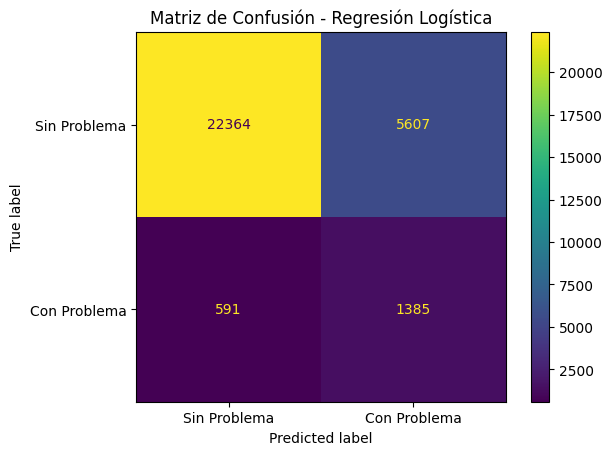

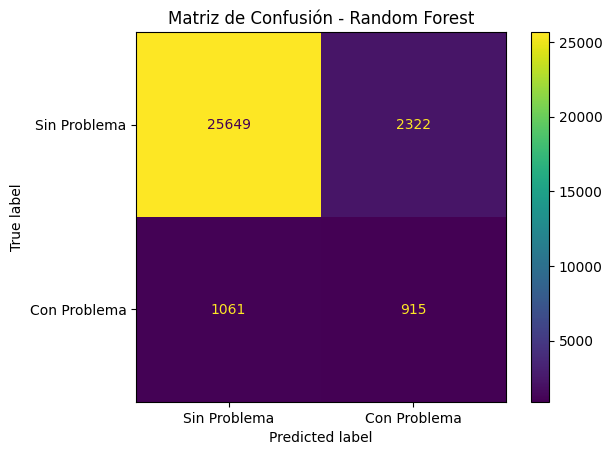

In [31]:
# Creamos la matriz de confusión de Random Forest y de Regresión Logística.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

modelos_finales = {
    'Regresión Logística' : modelo_logistic,
    'Random Forest' : modelo_rf
}

for nombre, modelo in modelos_finales.items():
    y_pred = modelo.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sin Problema', 'Con Problema'])
    disp.plot()
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.show()

## Observaciones de Matriz de Confusión de Regresión Logística:
- Hay 23.076 clientes sin riesgo que el modelo indica que no tienen riesgo de pago (TN)
- Hay 4.895 clientes sin riesgo que el modelo indica que sí tienen riesgo de pago (FP)
- Hay 701 clientes que tiene riesgo de impago y el modelo indica que no tienen riesgo (FN)
- Hay 1.275 clientes que tiene riesgo de impago, y el modelo lo confirma (TP)

## Observaciones de Matriz de Confusión de Random Forest:
- Hay 25.794 clientes sin riesgo que el modelo indica que lo confirma (TN)
- Hay 2.177 clientes sin riesgo que el modelo indica que sí tiene riesgo de impago (FP)
- Hay 1.088 clientes que tienen riesgo de impago y el modelo indica que no tienen dicho riesgo (FN)
- Hay 888 clientes que tienen riesgo y el modelo lo confirma (TP)

## Conclusiones generales:
- Regresión Logística detecta 1.275 impagos reales (TP) y se le escapan 701 (FN)
- Random Forest, le ocurre al contrario, detecta 888 impagos reales (TP) pero se escapa 1.088 casos (FN)
- La conclusión final es que considero que el uso de Random Forest es mucho más peligroso si el banco es bastante conservador a la hora de ofrecer créditos. Es preferible tener más FP (Falsos Positivos) porque solo genera molestia al cliente. Sin embargo, un FN (Falso Negativo) supone una pérdida económica real para la entidad bancaria.

## Paso 8 — Curva ROC y AUC
- Utilizamos curva ROC para que nos muestre una gráfica que no diga cómo se comporta el modelo a distintos umbrales de decisión.
- AUC (Area Under the Curve), la utilizaremos porque en clases desbalanceadas como nuestro caso es mucho más fiable que Accuracy para medir si nuestro modelo realmente distingue bien entre clientes con riesgo y sin el.

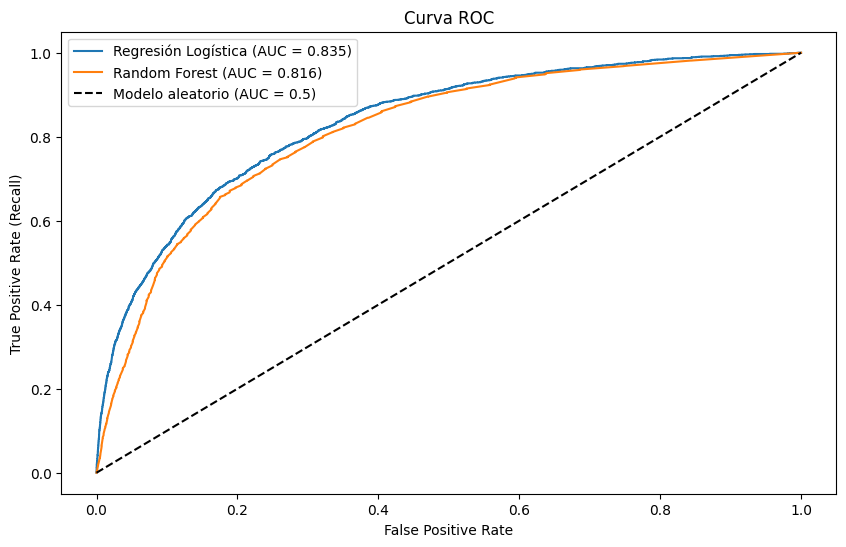

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score
plt.figure(figsize=(10,6))
for nombre, modelo in modelos_finales.items():
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1] #predict_prpba nos va a dar la probabilidad de ser de clase 1
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.3f})')

# Línea diagonal — representa un modelo aleatorio (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', label='Modelo aleatorio (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

## Observaciones:
- Las curvas ROC de Regresión Logística y Random Forest se encuentran por encima del modelo aleatorio, lo que nos lleva a la conclusión que los modelos son mejore que el azar
- Los AUC son de 0.823 y 0.821, considerando que los modelos son buenos 
- La diferencia entre los modelos es de 0.002 que es una diferencia muy pequeña
- En conclusiones generales, el banco puede confiar en estos modelos para distinguir clientes de riesgo, aunque estos modelos se pueden mejorar aún más.
- Para poder mejorarlos, usaremos hyperparameter tuning para intentar mejorar el rendimiento de los modelos.

## Paso 9 — Hyperparameter Tuning
- Buscamos la mejor combinación de hiperparámetros para mejorar el rendimiento del modelo con GridSearchCV

In [33]:
from sklearn.model_selection import GridSearchCV

# Definimos los hiperparámetros que queremos probar
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2]
}

# GridSearchCV prueba todas las combinaciones y elige la mejor
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train_scaled, y_train_smote)
print(f'Mejores parámetros: {grid_rf.best_params_}')
print(f'Mejor F1: {grid_rf.best_score_:.4f}')

Mejores parámetros: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Mejor F1: 0.9215


In [34]:
# F1 da un valor de 0.93 sobre SMOTE. Evaluamos el modelo optimizado sobre el test real
from sklearn.metrics import classification_report, roc_auc_score
y_pred_rf_tuned = grid_rf.best_estimator_.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf_tuned))
print(f'AUC: {roc_auc_score(y_test, grid_rf.best_estimator_.predict_proba(X_test_scaled)[:, 1]):.4f}')

              precision    recall  f1-score   support

           0       0.96      0.92      0.94     27971
           1       0.28      0.46      0.35      1976

    accuracy                           0.89     29947
   macro avg       0.62      0.69      0.64     29947
weighted avg       0.92      0.89      0.90     29947

AUC: 0.8176


## Observaciones:
- F1 en TRAIN con SMOTE es de 0.93, y en test real es de 0.36. Es una diferencia muy grande que nos indica que hay overfitting, es decir, el modelo aprende muy bien pero no generaliza los datos nuevos.
- Si comparamos los datos antes del tuning podemos ver, que la mejora ha sido mínima, casi imperceptible

In [35]:
# Ahora repetimos la operación para Regresión Logística
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'max_iter': [100, 200, 500]
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train_smote)
print(f'Mejores parámetros: {grid_lr.best_params_}')
print(f'Mejor F1: {grid_lr.best_score_:.4f}')

Mejores parámetros: {'C': 0.01, 'max_iter': 100}
Mejor F1: 0.7779


In [36]:
from sklearn.metrics import classification_report, roc_auc_score

# Evaluamos la Regresión Logística optimizada sobre el test real
y_pred_lr_tuned = grid_lr.best_estimator_.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr_tuned))
print(f'AUC: {roc_auc_score(y_test, grid_lr.best_estimator_.predict_proba(X_test_scaled)[:, 1]):.4f}')

              precision    recall  f1-score   support

           0       0.97      0.80      0.88     27971
           1       0.20      0.70      0.31      1976

    accuracy                           0.79     29947
   macro avg       0.59      0.75      0.59     29947
weighted avg       0.92      0.79      0.84     29947

AUC: 0.8353


## Observaciones:
- Igual que con Random Forest, en Regresión Logística, si comparamos los datos antes del tuning, son prácticamente similares, no hay una mejora significativa.
- Los mejores parámetros encontrados son C=0.01 y max_iter=100. C=0.01 indica una regularización fuerte — el modelo es más simple y conservador, lo que ayuda a evitar overfitting.